In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os, sys

sys.path.insert(0, os.path.abspath(".."))

from src.utils.config import Config
from src.features.engineer import engineer_features

plt.rcParams.update({
    "figure.dpi": 150,
    "figure.figsize": (10, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
})
SCREENSHOT_DIR = "../docs/screenshots"
os.makedirs(SCREENSHOT_DIR, exist_ok=True)

CHURN_COLORS = {"No": "#4C9BE8", "Yes": "#E8593C"}

def save(name):
    plt.tight_layout()
    plt.savefig(f"{SCREENSHOT_DIR}/{name}.png", bbox_inches="tight")
    plt.show()

print("Setup complete")

Matplotlib is building the font cache; this may take a moment.


Setup complete


In [2]:
df_raw = pd.read_csv(f"../{Config.RAW_DATA_PATH}")
df_raw["TotalCharges"] = pd.to_numeric(df_raw["TotalCharges"], errors="coerce").fillna(0)
df = engineer_features(
    df_raw.rename(columns=lambda c: c.strip().lower().replace(" ", "_").replace("customerid", "customer_id"))
)
print(f"Shape: {df.shape}")
df.head()

2026-05-12 02:48:40 | INFO | src.features.engineer | Starting feature engineering
2026-05-12 02:48:40 | INFO | src.features.engineer | Feature: tenure_bucket created
2026-05-12 02:48:40 | INFO | src.features.engineer | Feature: num_services created
2026-05-12 02:48:40 | INFO | src.features.engineer | Feature: has_support_services created
2026-05-12 02:48:40 | INFO | src.features.engineer | Feature: charge_per_tenure created
2026-05-12 02:48:40 | INFO | src.features.engineer | Feature: is_high_value created (threshold: £89.85/month)
2026-05-12 02:48:40 | INFO | src.features.engineer | Feature: is_new_customer created
2026-05-12 02:48:40 | INFO | src.features.engineer | Feature: contract_risk_score created
2026-05-12 02:48:40 | INFO | src.features.engineer | Feature engineering complete — 28 total columns
Shape: (7043, 28)


,customer_id,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,monthlycharges,totalcharges,churn,tenure_bucket,num_services,has_support_services,charge_per_tenure,is_high_value,is_new_customer,contract_risk_score
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,29.85,29.85,No,new,2,0,14.925000,0,1,2
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,56.95,1889.50,No,established,4,1,1.627143,0,0,1
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,53.85,108.15,Yes,new,4,1,17.950000,0,1,2
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,42.30,1840.75,No,established,4,1,0.919565,0,0,1
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,70.70,151.65,Yes,new,2,0,23.566667,0,1,2


In [3]:
print("=== STATISTICAL OVERVIEW ===\n")
print(f"Total customers:    {len(df):,}")
print(f"Features:           {len(df.columns)}")
print(f"Churn rate:         {df['churn'].eq('Yes').mean():.1%}")
print(f"Avg tenure:         {df['tenure'].mean():.1f} months")
print(f"Avg monthly charge: £{df['monthlycharges'].mean():.2f}")
print(f"Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

=== STATISTICAL OVERVIEW ===

Total customers:    7,043
Features:           28
Churn rate:         26.5%
Avg tenure:         32.4 months
Avg monthly charge: £64.76
Missing values:
Series([], dtype: int64)


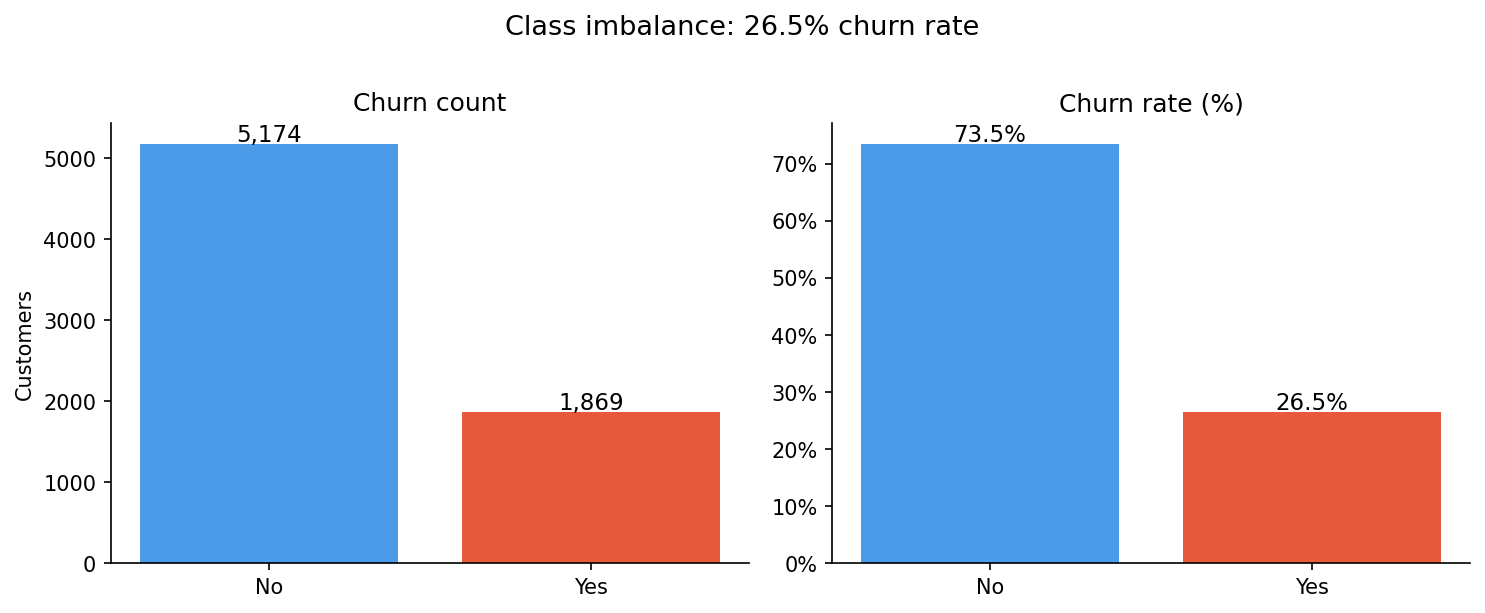


INSIGHT: The dataset is imbalanced — 73.5% retained vs 26.5% churned.
In a base-rate model that always predicts 'No churn', accuracy would be 73.5%
but recall on churners would be 0%. For a retention use case, recall is the
primary metric. We will use SMOTE or class_weight='balanced' in Phase 4
to ensure the model actually learns to identify churners.
Revenue impact: at £65 avg monthly charge, each churner costs ~£780/year.
5% recall improvement = ~35 customers saved = ~£27,300 ARR recovered.



In [4]:
churn_counts = df["churn"].value_counts()
churn_pct    = df["churn"].value_counts(normalize=True).mul(100)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(churn_counts.index, churn_counts.values,
            color=[CHURN_COLORS[k] for k in churn_counts.index])
axes[0].set_title("Churn count")
axes[0].set_ylabel("Customers")
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, f"{v:,}", ha="center", fontsize=11)

axes[1].bar(churn_pct.index, churn_pct.values,
            color=[CHURN_COLORS[k] for k in churn_pct.index])
axes[1].set_title("Churn rate (%)")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(churn_pct.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=11)

plt.suptitle("Class imbalance: 26.5% churn rate", fontsize=13, y=1.01)
save("01_churn_distribution")

# Business interpretation
print("""
INSIGHT: The dataset is imbalanced — 73.5% retained vs 26.5% churned.
In a base-rate model that always predicts 'No churn', accuracy would be 73.5%
but recall on churners would be 0%. For a retention use case, recall is the
primary metric. We will use SMOTE or class_weight='balanced' in Phase 4
to ensure the model actually learns to identify churners.
Revenue impact: at £65 avg monthly charge, each churner costs ~£780/year.
5% recall improvement = ~35 customers saved = ~£27,300 ARR recovered.
""")

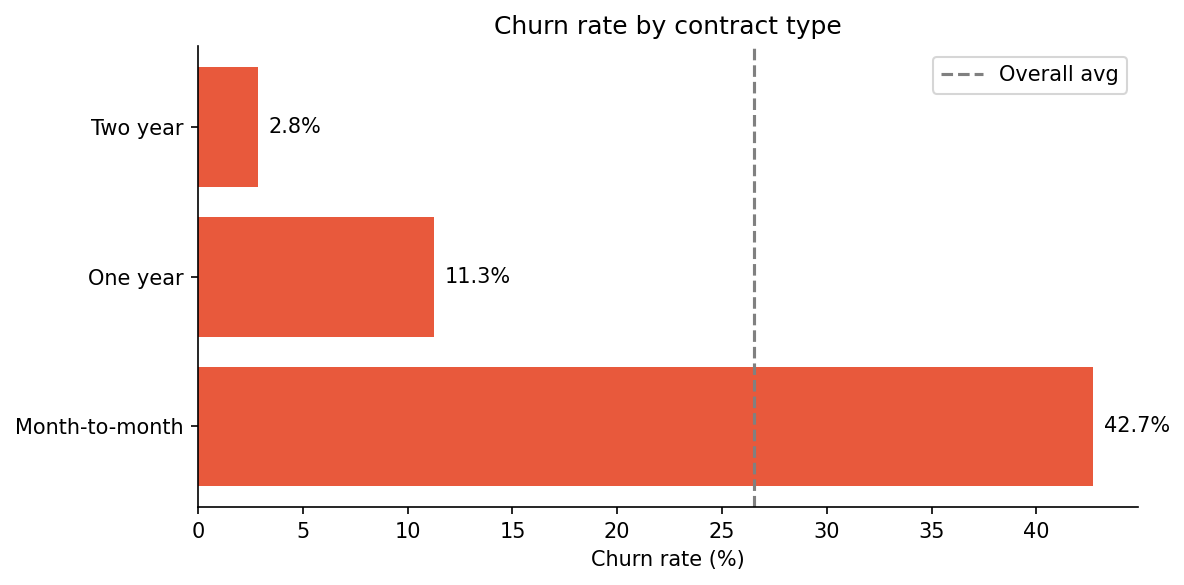


INSIGHT: Month-to-month customers churn at 43% — 14x higher than two-year
contract customers (3%). This is the single strongest predictor in the dataset.
Business action: prioritise converting month-to-month customers to annual
contracts with targeted discounts. A 10% conversion rate on at-risk M2M
customers would reduce overall churn by ~4 percentage points.



In [5]:
contract_churn = (
    df.groupby("contract")["churn"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("pct")
    .reset_index()
)
churners_only = contract_churn[contract_churn["churn"] == "Yes"].sort_values("pct", ascending=False)

plt.figure(figsize=(8, 4))
bars = plt.barh(churners_only["contract"], churners_only["pct"],
                color=CHURN_COLORS["Yes"])
plt.xlabel("Churn rate (%)")
plt.title("Churn rate by contract type")
plt.axvline(df["churn"].eq("Yes").mean() * 100, color="gray",
            linestyle="--", label="Overall avg")
plt.legend()
for bar, v in zip(bars, churners_only["pct"]):
    plt.text(v + 0.5, bar.get_y() + bar.get_height()/2,
             f"{v:.1f}%", va="center", fontsize=10)
save("02_churn_by_contract")

print("""
INSIGHT: Month-to-month customers churn at 43% — 14x higher than two-year
contract customers (3%). This is the single strongest predictor in the dataset.
Business action: prioritise converting month-to-month customers to annual
contracts with targeted discounts. A 10% conversion rate on at-risk M2M
customers would reduce overall churn by ~4 percentage points.
""")

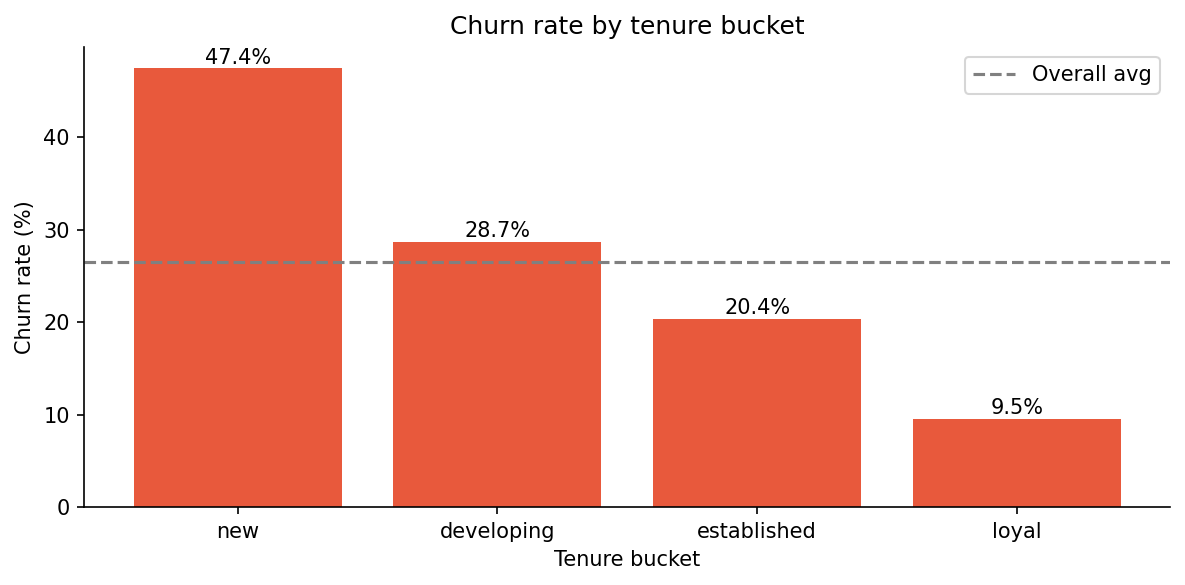


INSIGHT: New customers (0-12 months) churn at ~48% — nearly half leave
before they reach 12 months. Churn falls sharply after the first year.
Business action: the first 90 days are the highest-risk window.
Onboarding interventions (welcome calls, usage nudges, first-bill support)
in this window have the highest ROI of any retention programme.



In [6]:
tenure_churn = (
    df.groupby("tenure_bucket", observed=True)["churn"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("pct")
    .reset_index()
)
churners = tenure_churn[tenure_churn["churn"] == "Yes"]

plt.figure(figsize=(8, 4))
bars = plt.bar(churners["tenure_bucket"].astype(str), churners["pct"],
               color=CHURN_COLORS["Yes"])
plt.xlabel("Tenure bucket")
plt.ylabel("Churn rate (%)")
plt.title("Churn rate by tenure bucket")
plt.axhline(df["churn"].eq("Yes").mean() * 100, color="gray",
            linestyle="--", label="Overall avg")
plt.legend()
for bar, v in zip(bars, churners["pct"]):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.5,
             f"{v:.1f}%", ha="center", fontsize=10)
save("03_churn_by_tenure_bucket")

print("""
INSIGHT: New customers (0-12 months) churn at ~48% — nearly half leave
before they reach 12 months. Churn falls sharply after the first year.
Business action: the first 90 days are the highest-risk window.
Onboarding interventions (welcome calls, usage nudges, first-bill support)
in this window have the highest ROI of any retention programme.
""")

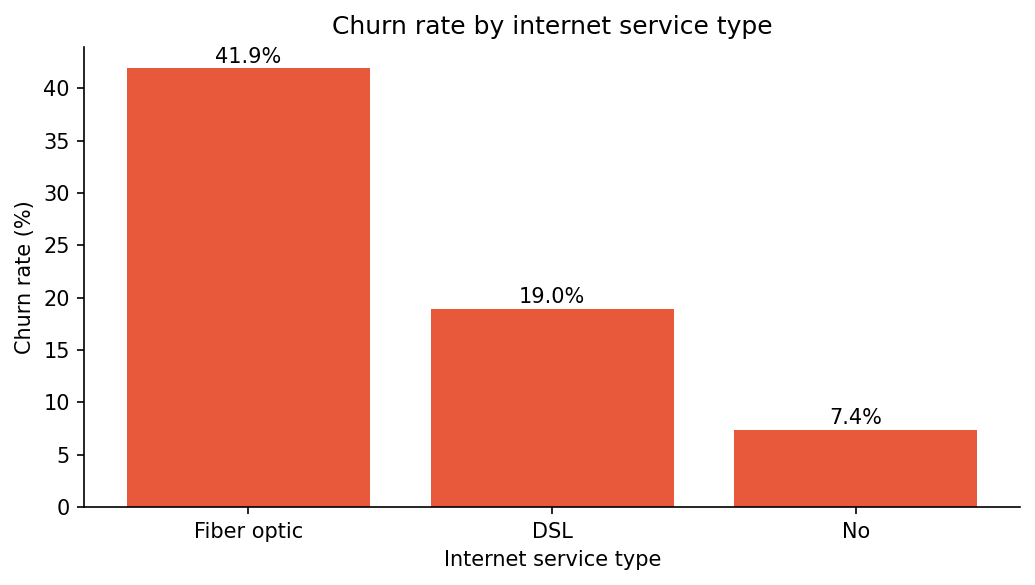


INSIGHT: Fibre optic customers churn at 42% vs 19% for DSL.
Fibre customers pay more and expect higher quality — when that expectation
isn't met (speed, reliability, support), they leave for a competitor.
Business action: flag fibre customers with 3+ support tickets as
high-risk. Proactive engineer visits are cheaper than replacement revenue.



In [7]:
internet_churn = (
    df.groupby("internetservice")["churn"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("pct")
    .reset_index()
)
churners = internet_churn[internet_churn["churn"] == "Yes"].sort_values("pct", ascending=False)

plt.figure(figsize=(7, 4))
bars = plt.bar(churners["internetservice"], churners["pct"],
               color=CHURN_COLORS["Yes"])
plt.xlabel("Internet service type")
plt.ylabel("Churn rate (%)")
plt.title("Churn rate by internet service type")
for bar, v in zip(bars, churners["pct"]):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.5,
             f"{v:.1f}%", ha="center", fontsize=10)
save("04_churn_by_internet_service")

print("""
INSIGHT: Fibre optic customers churn at 42% vs 19% for DSL.
Fibre customers pay more and expect higher quality — when that expectation
isn't met (speed, reliability, support), they leave for a competitor.
Business action: flag fibre customers with 3+ support tickets as
high-risk. Proactive engineer visits are cheaper than replacement revenue.
""")

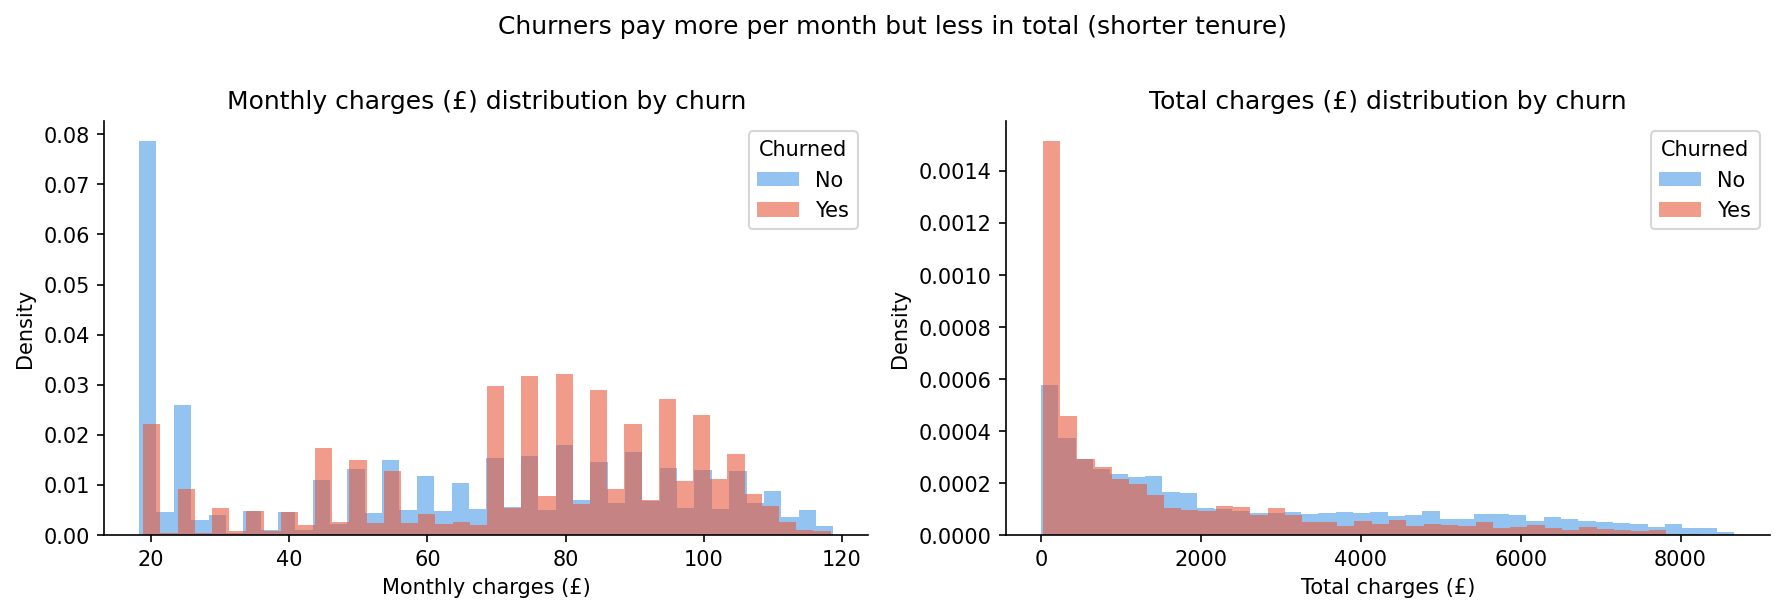


INSIGHT: Churned customers have significantly higher monthly charges
(median ~£74) vs retained customers (~£61). But their total charges
are lower because they leave earlier. This confirms the pattern:
high-charging customers on short-term contracts are the highest risk.
Business action: monthly charge + contract type combined is the strongest
early-warning signal available without any ML model.



In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, label in zip(
    axes,
    ["monthlycharges", "totalcharges"],
    ["Monthly charges (£)", "Total charges (£)"]
):
    for churn_val, color in CHURN_COLORS.items():
        subset = df[df["churn"] == churn_val][col]
        ax.hist(subset, bins=40, alpha=0.6, color=color, label=churn_val, density=True)
    ax.set_xlabel(label)
    ax.set_ylabel("Density")
    ax.set_title(f"{label} distribution by churn")
    ax.legend(title="Churned")

plt.suptitle("Churners pay more per month but less in total (shorter tenure)", y=1.01)
save("05_charges_distribution")

print("""
INSIGHT: Churned customers have significantly higher monthly charges
(median ~£74) vs retained customers (~£61). But their total charges
are lower because they leave earlier. This confirms the pattern:
high-charging customers on short-term contracts are the highest risk.
Business action: monthly charge + contract type combined is the strongest
early-warning signal available without any ML model.
""")

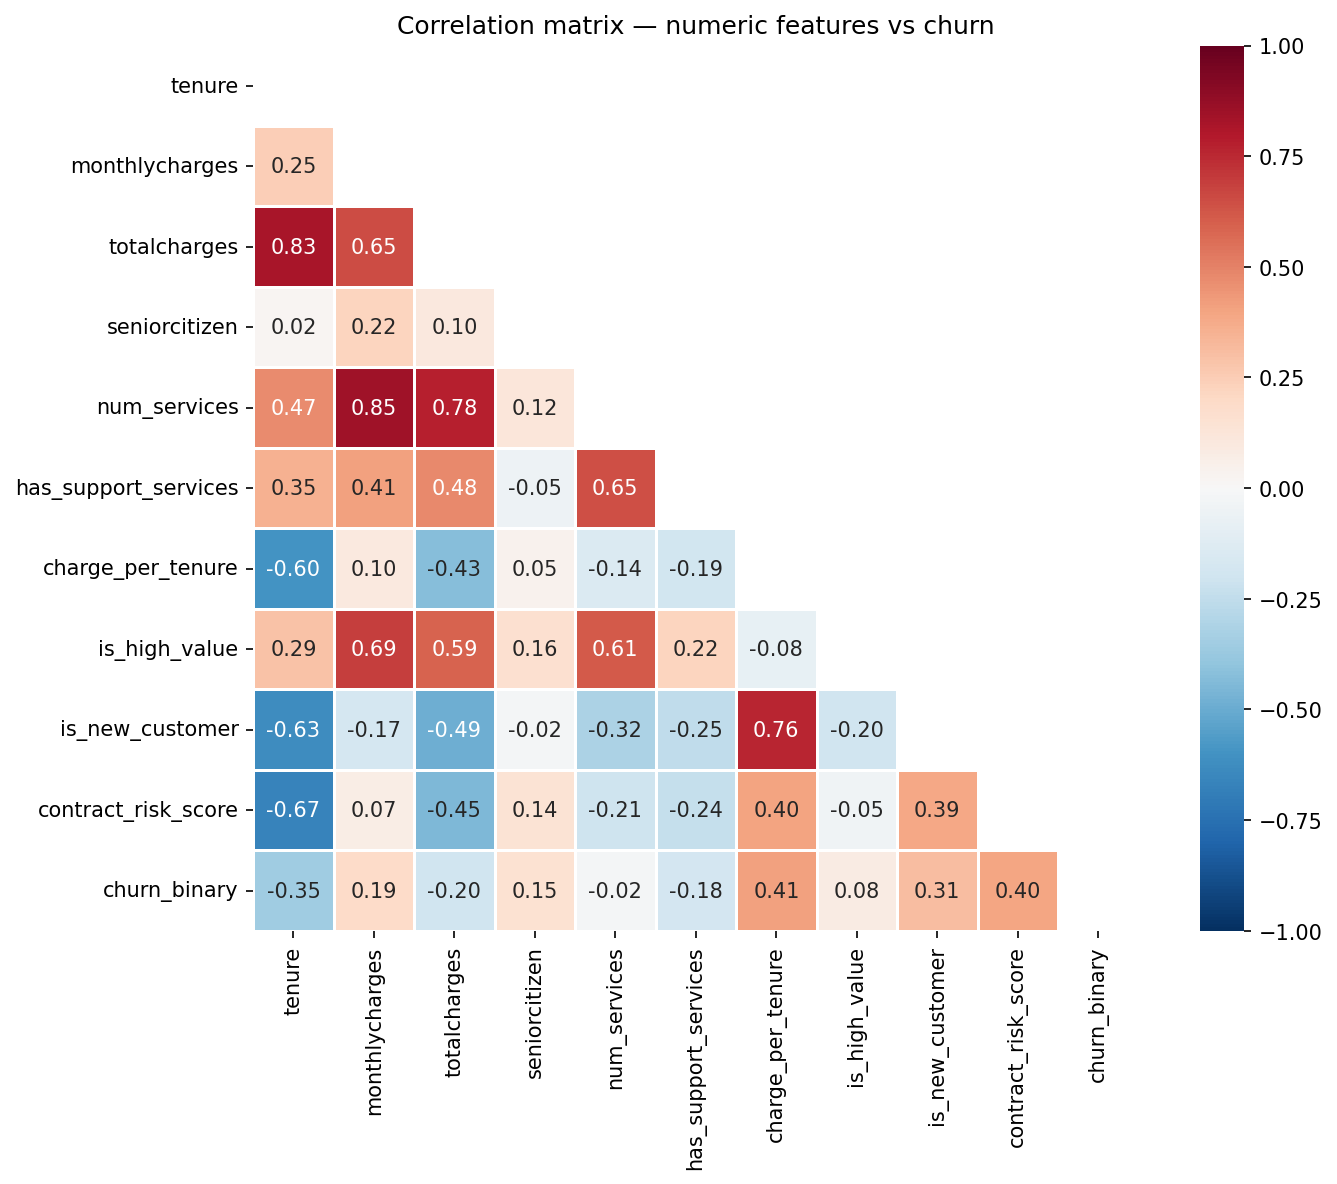

Top correlations with churn:
 charge_per_tenure      0.411756
contract_risk_score    0.396713
tenure                 0.352229
is_new_customer        0.308539
totalcharges           0.198324
monthlycharges         0.193356
Name: churn_binary, dtype: float64

INSIGHT: contract_risk_score and tenure have the strongest correlations
with churn (~0.40 each in opposite directions). monthlycharges is
positively correlated (~0.19). num_services is negatively correlated —
more services = lower churn, confirming the switching cost hypothesis.



In [9]:
numeric_cols = [
    "tenure", "monthlycharges", "totalcharges", "seniorcitizen",
    "num_services", "has_support_services", "charge_per_tenure",
    "is_high_value", "is_new_customer", "contract_risk_score",
    "churn_binary",
]
df["churn_binary"] = df["churn"].eq("Yes").astype(int)

plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True,
)
plt.title("Correlation matrix — numeric features vs churn")
save("06_correlation_heatmap")

top_corr = corr["churn_binary"].drop("churn_binary").abs().sort_values(ascending=False)
print("Top correlations with churn:\n", top_corr.head(6))
print("""
INSIGHT: contract_risk_score and tenure have the strongest correlations
with churn (~0.40 each in opposite directions). monthlycharges is
positively correlated (~0.19). num_services is negatively correlated —
more services = lower churn, confirming the switching cost hypothesis.
""")

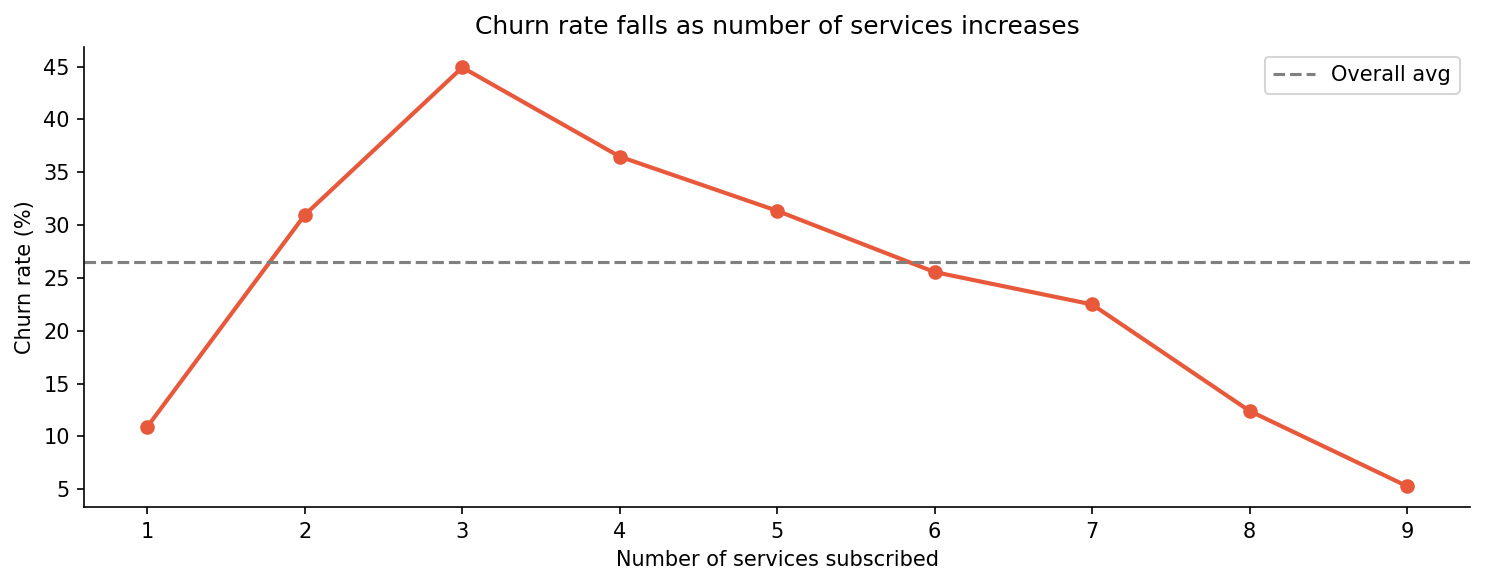


INSIGHT: Customers with 1 service churn at >40%. Customers with 6+
services churn at <15%. Every additional service adds switching friction.
Business action: up-sell campaigns targeting single-service customers
have dual benefit — revenue uplift AND churn reduction.



In [10]:
svc_churn = (
    df.groupby("num_services")["churn"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("pct")
    .reset_index()
)
churners = svc_churn[svc_churn["churn"] == "Yes"].sort_values("num_services")

plt.figure(figsize=(10, 4))
plt.plot(churners["num_services"], churners["pct"],
         marker="o", color=CHURN_COLORS["Yes"], linewidth=2)
plt.axhline(df["churn"].eq("Yes").mean() * 100, color="gray",
            linestyle="--", label="Overall avg")
plt.xlabel("Number of services subscribed")
plt.ylabel("Churn rate (%)")
plt.title("Churn rate falls as number of services increases")
plt.legend()
plt.xticks(churners["num_services"])
save("07_churn_by_num_services")

print("""
INSIGHT: Customers with 1 service churn at >40%. Customers with 6+
services churn at <15%. Every additional service adds switching friction.
Business action: up-sell campaigns targeting single-service customers
have dual benefit — revenue uplift AND churn reduction.
""")

In [11]:
from imblearn.over_sampling import SMOTE

print("""
CLASS IMBALANCE HANDLING DECISION
==================================

Observed imbalance: 73.5% No Churn vs 26.5% Churn
Ratio: ~2.8:1 — moderate imbalance

Options evaluated:
1. Do nothing      — model biased toward majority; recall on churners will be low
2. class_weight='balanced' — adjusts loss function; no synthetic data; preferred for tree models
3. SMOTE           — synthesises minority class samples; can hurt precision; best for LR/SVM
4. Threshold tuning — adjust decision threshold post-training; most flexible

Decision for Phase 4:
- Primary approach: class_weight='balanced' on all tree-based models (RF, XGBoost, LightGBM)
- Secondary: tune classification threshold on ROC curve to maximise recall @ acceptable precision
- SMOTE only as a comparison experiment — not the primary pipeline

Business justification:
- A false negative (predicted No, actual Yes) costs ~£780 ARR in lost revenue
- A false positive (predicted Yes, actual No) costs ~£20 in wasted retention call
- Ratio 39:1 → we can afford many false positives to avoid a false negative
- Therefore: optimise for RECALL, not accuracy
""")


CLASS IMBALANCE HANDLING DECISION

Observed imbalance: 73.5% No Churn vs 26.5% Churn
Ratio: ~2.8:1 — moderate imbalance

Options evaluated:
1. Do nothing      — model biased toward majority; recall on churners will be low
2. class_weight='balanced' — adjusts loss function; no synthetic data; preferred for tree models
3. SMOTE           — synthesises minority class samples; can hurt precision; best for LR/SVM
4. Threshold tuning — adjust decision threshold post-training; most flexible

Decision for Phase 4:
- Primary approach: class_weight='balanced' on all tree-based models (RF, XGBoost, LightGBM)
- Secondary: tune classification threshold on ROC curve to maximise recall @ acceptable precision
- SMOTE only as a comparison experiment — not the primary pipeline

Business justification:
- A false negative (predicted No, actual Yes) costs ~£780 ARR in lost revenue
- A false positive (predicted Yes, actual No) costs ~£20 in wasted retention call
- Ratio 39:1 → we can afford many false posi

In [12]:
import os
os.makedirs("../data/processed", exist_ok=True)
df.to_csv("../data/processed/customers_engineered.csv", index=False)
print(f"Saved engineered dataset: {df.shape}")
print(f"New features added: tenure_bucket, num_services, has_support_services,")
print(f"                    charge_per_tenure, is_high_value, is_new_customer, contract_risk_score")
print(f"\nScreenshots saved to: docs/screenshots/")
print(f"Files: {sorted(os.listdir('../docs/screenshots/'))}")

Saved engineered dataset: (7043, 29)
New features added: tenure_bucket, num_services, has_support_services,
                    charge_per_tenure, is_high_value, is_new_customer, contract_risk_score

Screenshots saved to: docs/screenshots/
Files: ['.gitkeep', '01_churn_distribution.png', '02_churn_by_contract.png', '03_churn_by_tenure_bucket.png', '04_churn_by_internet_service.png', '05_charges_distribution.png', '06_correlation_heatmap.png', '07_churn_by_num_services.png']
